['CFSAUID', 'PRUID', 'PRNAME', 'geometry']


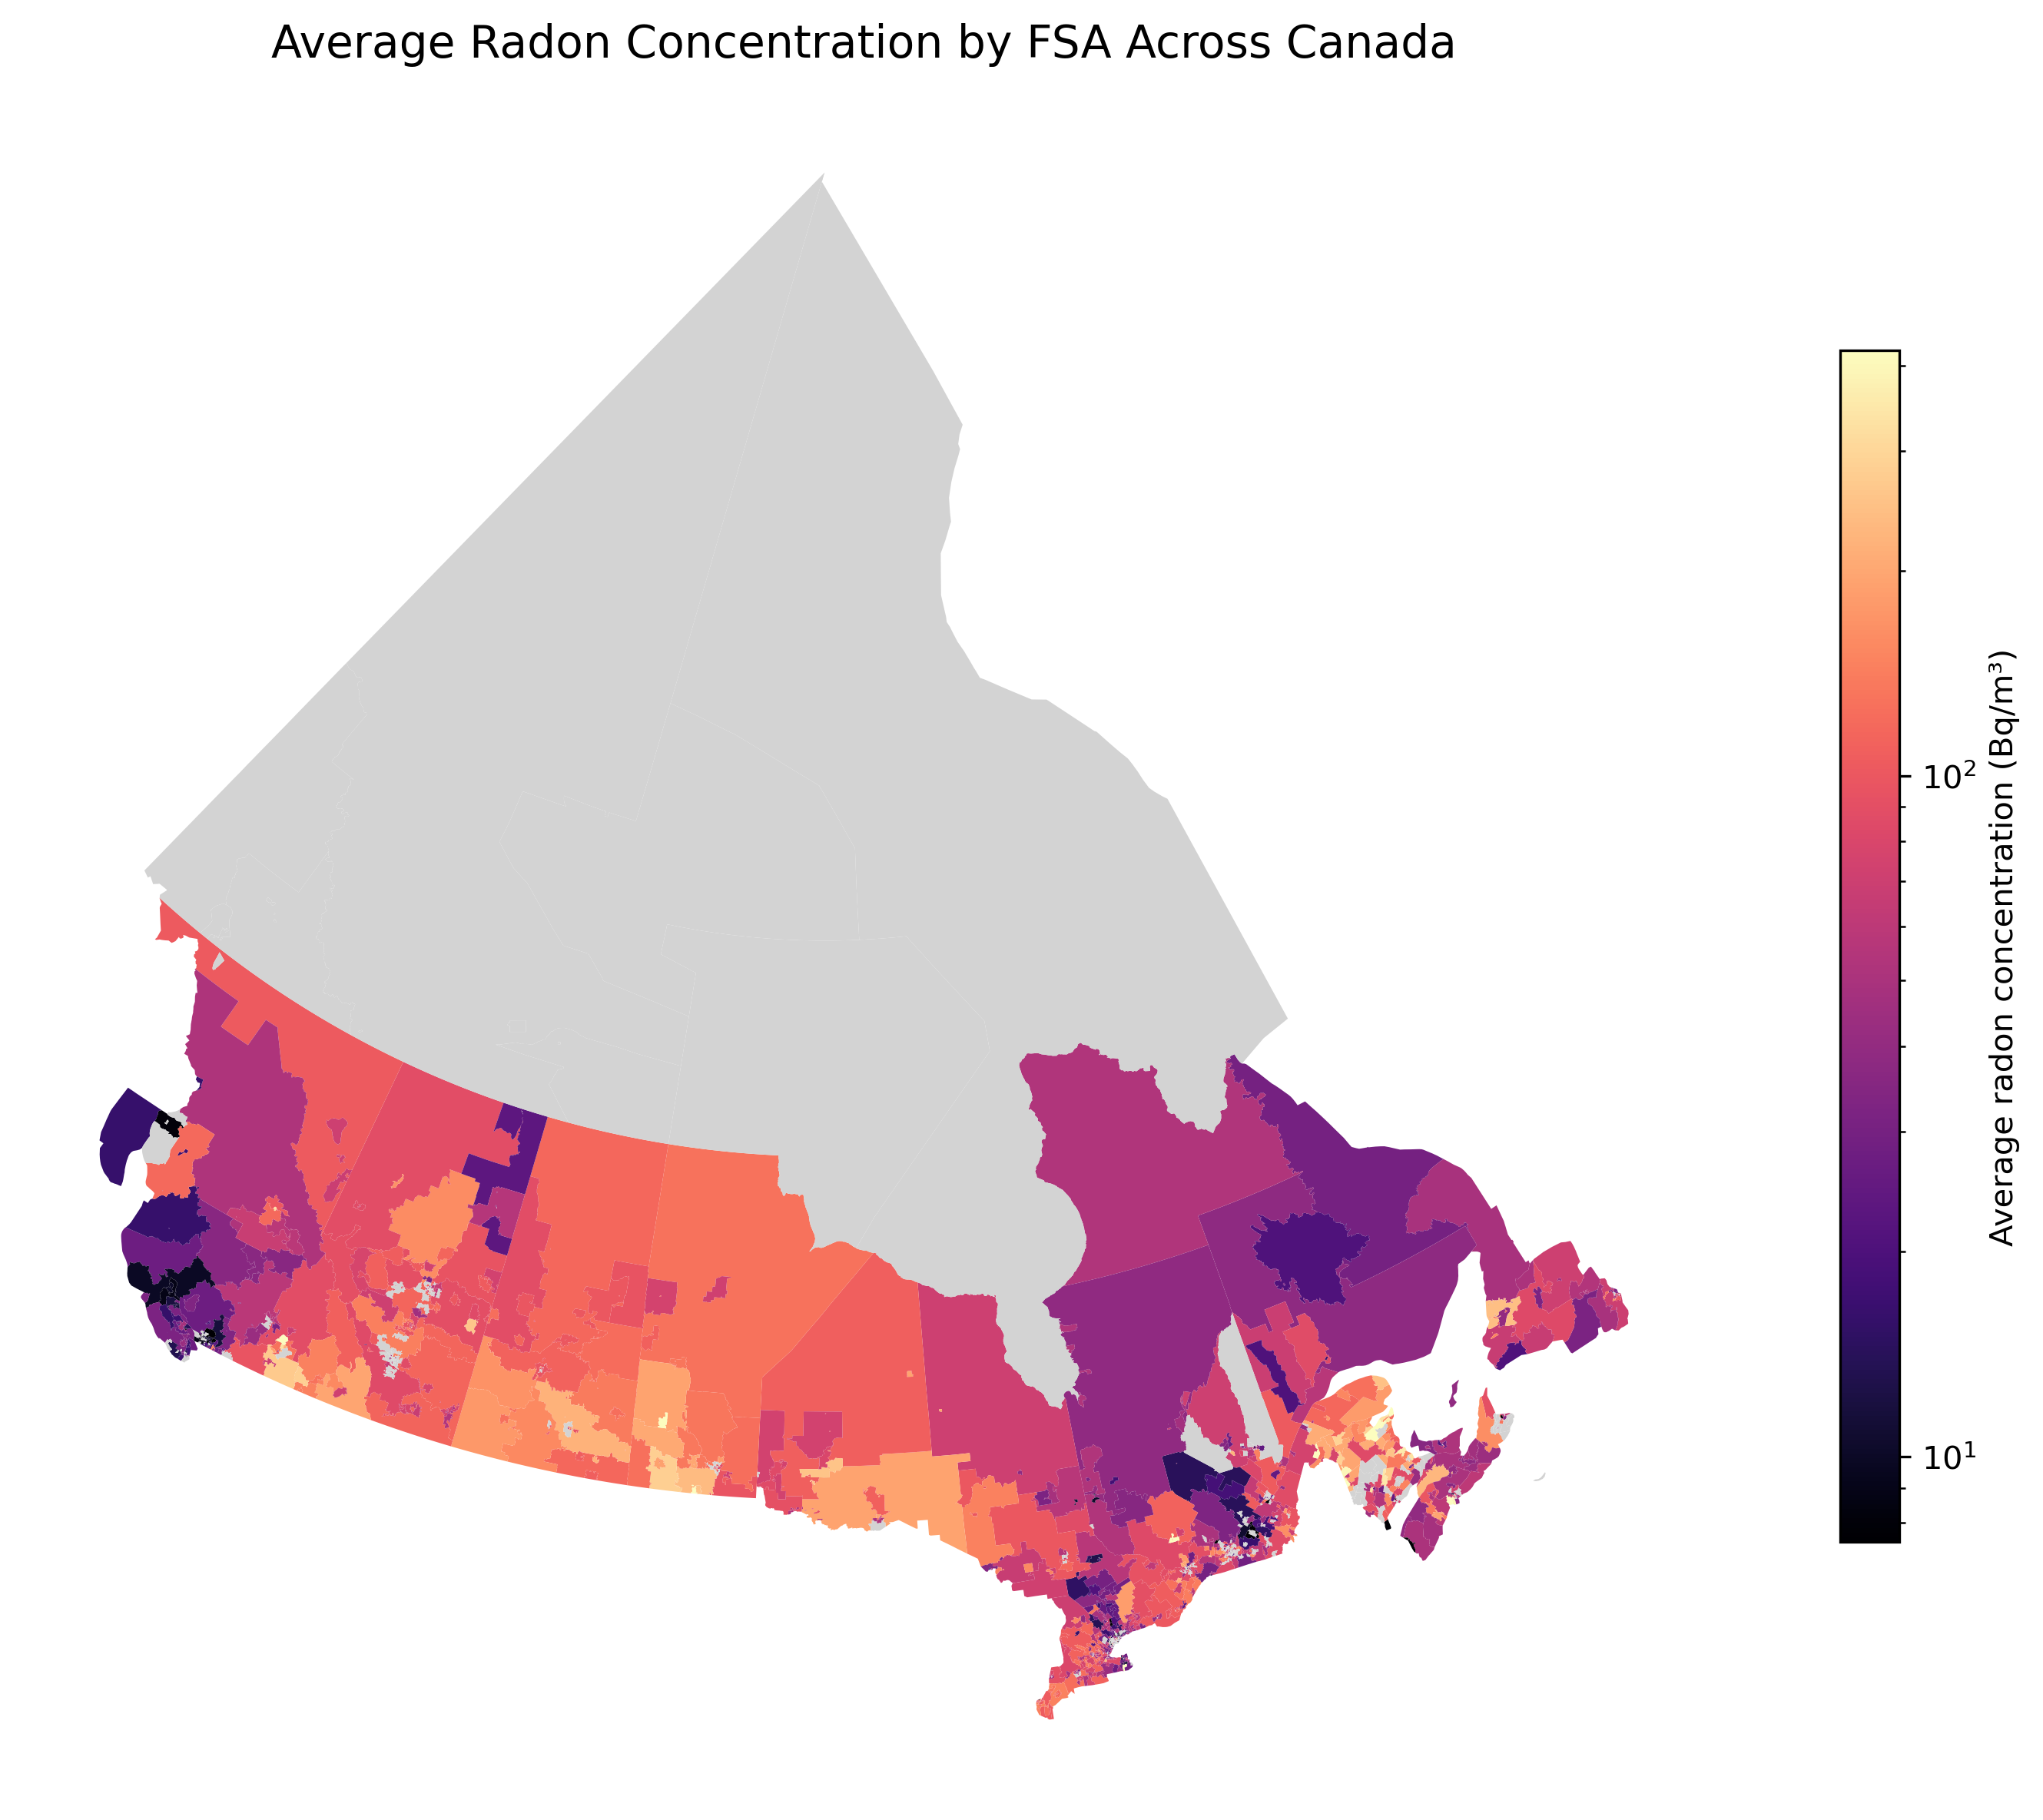

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
import sys
import os

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

from config.paths import FSA_BOUNDARY_SHAPEFILE
from config.paths import MAIN_DATASET
from config.paths import FIGURES_DIR

# ------------------------------------------------------------
# Load tabular radon data
# ------------------------------------------------------------
data = pd.read_csv(MAIN_DATASET)

# Average concentration by FSA
mean_concentration_by_fsa = (
    data.groupby("FSA", as_index=False)
    .agg(
        concentration_mean=("concentration", "mean"),
        provinceterritory=("provinceterritory", "first")
    )
)

# ------------------------------------------------------------
# Load FSA polygons
# ------------------------------------------------------------
fsa_boundaries = gpd.read_file(FSA_BOUNDARY_SHAPEFILE)

print(fsa_boundaries.columns.tolist())  # inspect once to confirm the FSA key column

# ------------------------------------------------------------
# Choose the FSA ID column in the shapefile
# Replace this if needed after checking the printed columns
# Common possibilities: "FSA", "CFSAUID"
# ------------------------------------------------------------
if "FSA" in fsa_boundaries.columns:
    shapefile_fsa_column = "FSA"
elif "CFSAUID" in fsa_boundaries.columns:
    shapefile_fsa_column = "CFSAUID"
else:
    raise ValueError(
        "Could not find the FSA identifier column in the shapefile. "
        "Check the printed columns and set shapefile_fsa_column manually."
    )

# Make sure both sides are strings
fsa_boundaries[shapefile_fsa_column] = fsa_boundaries[shapefile_fsa_column].astype(str)
mean_concentration_by_fsa["FSA"] = mean_concentration_by_fsa["FSA"].astype(str)

# Merge concentration data onto polygons
fsa_map = fsa_boundaries.merge(
    mean_concentration_by_fsa,
    left_on=shapefile_fsa_column,
    right_on="FSA",
    how="left"
)

# Optional: project to a Canada-friendly CRS for plotting
if fsa_map.crs is not None:
    fsa_map = fsa_map.to_crs("EPSG:3347")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

positive_values = fsa_map.loc[
    fsa_map["concentration_mean"].notna() & (fsa_map["concentration_mean"] > 0),
    "concentration_mean"
]

vmin = max(positive_values.min(), 1)
vmax = positive_values.quantile(0.99)

fsa_map.plot(
    column="concentration_mean",
    cmap="magma",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    linewidth=0.05,
    edgecolor="none",
    legend=True,
    legend_kwds={
        "label": "Average radon concentration (Bq/m³)",
        "shrink": 0.7
    },
    missing_kwds={
        "color": "lightgray",
        "label": "No data"
    },
    ax=ax
)

ax.set_title("Average Radon Concentration by FSA Across Canada", fontsize=14, pad=12)
ax.set_axis_off()

plt.tight_layout()
plt.show()

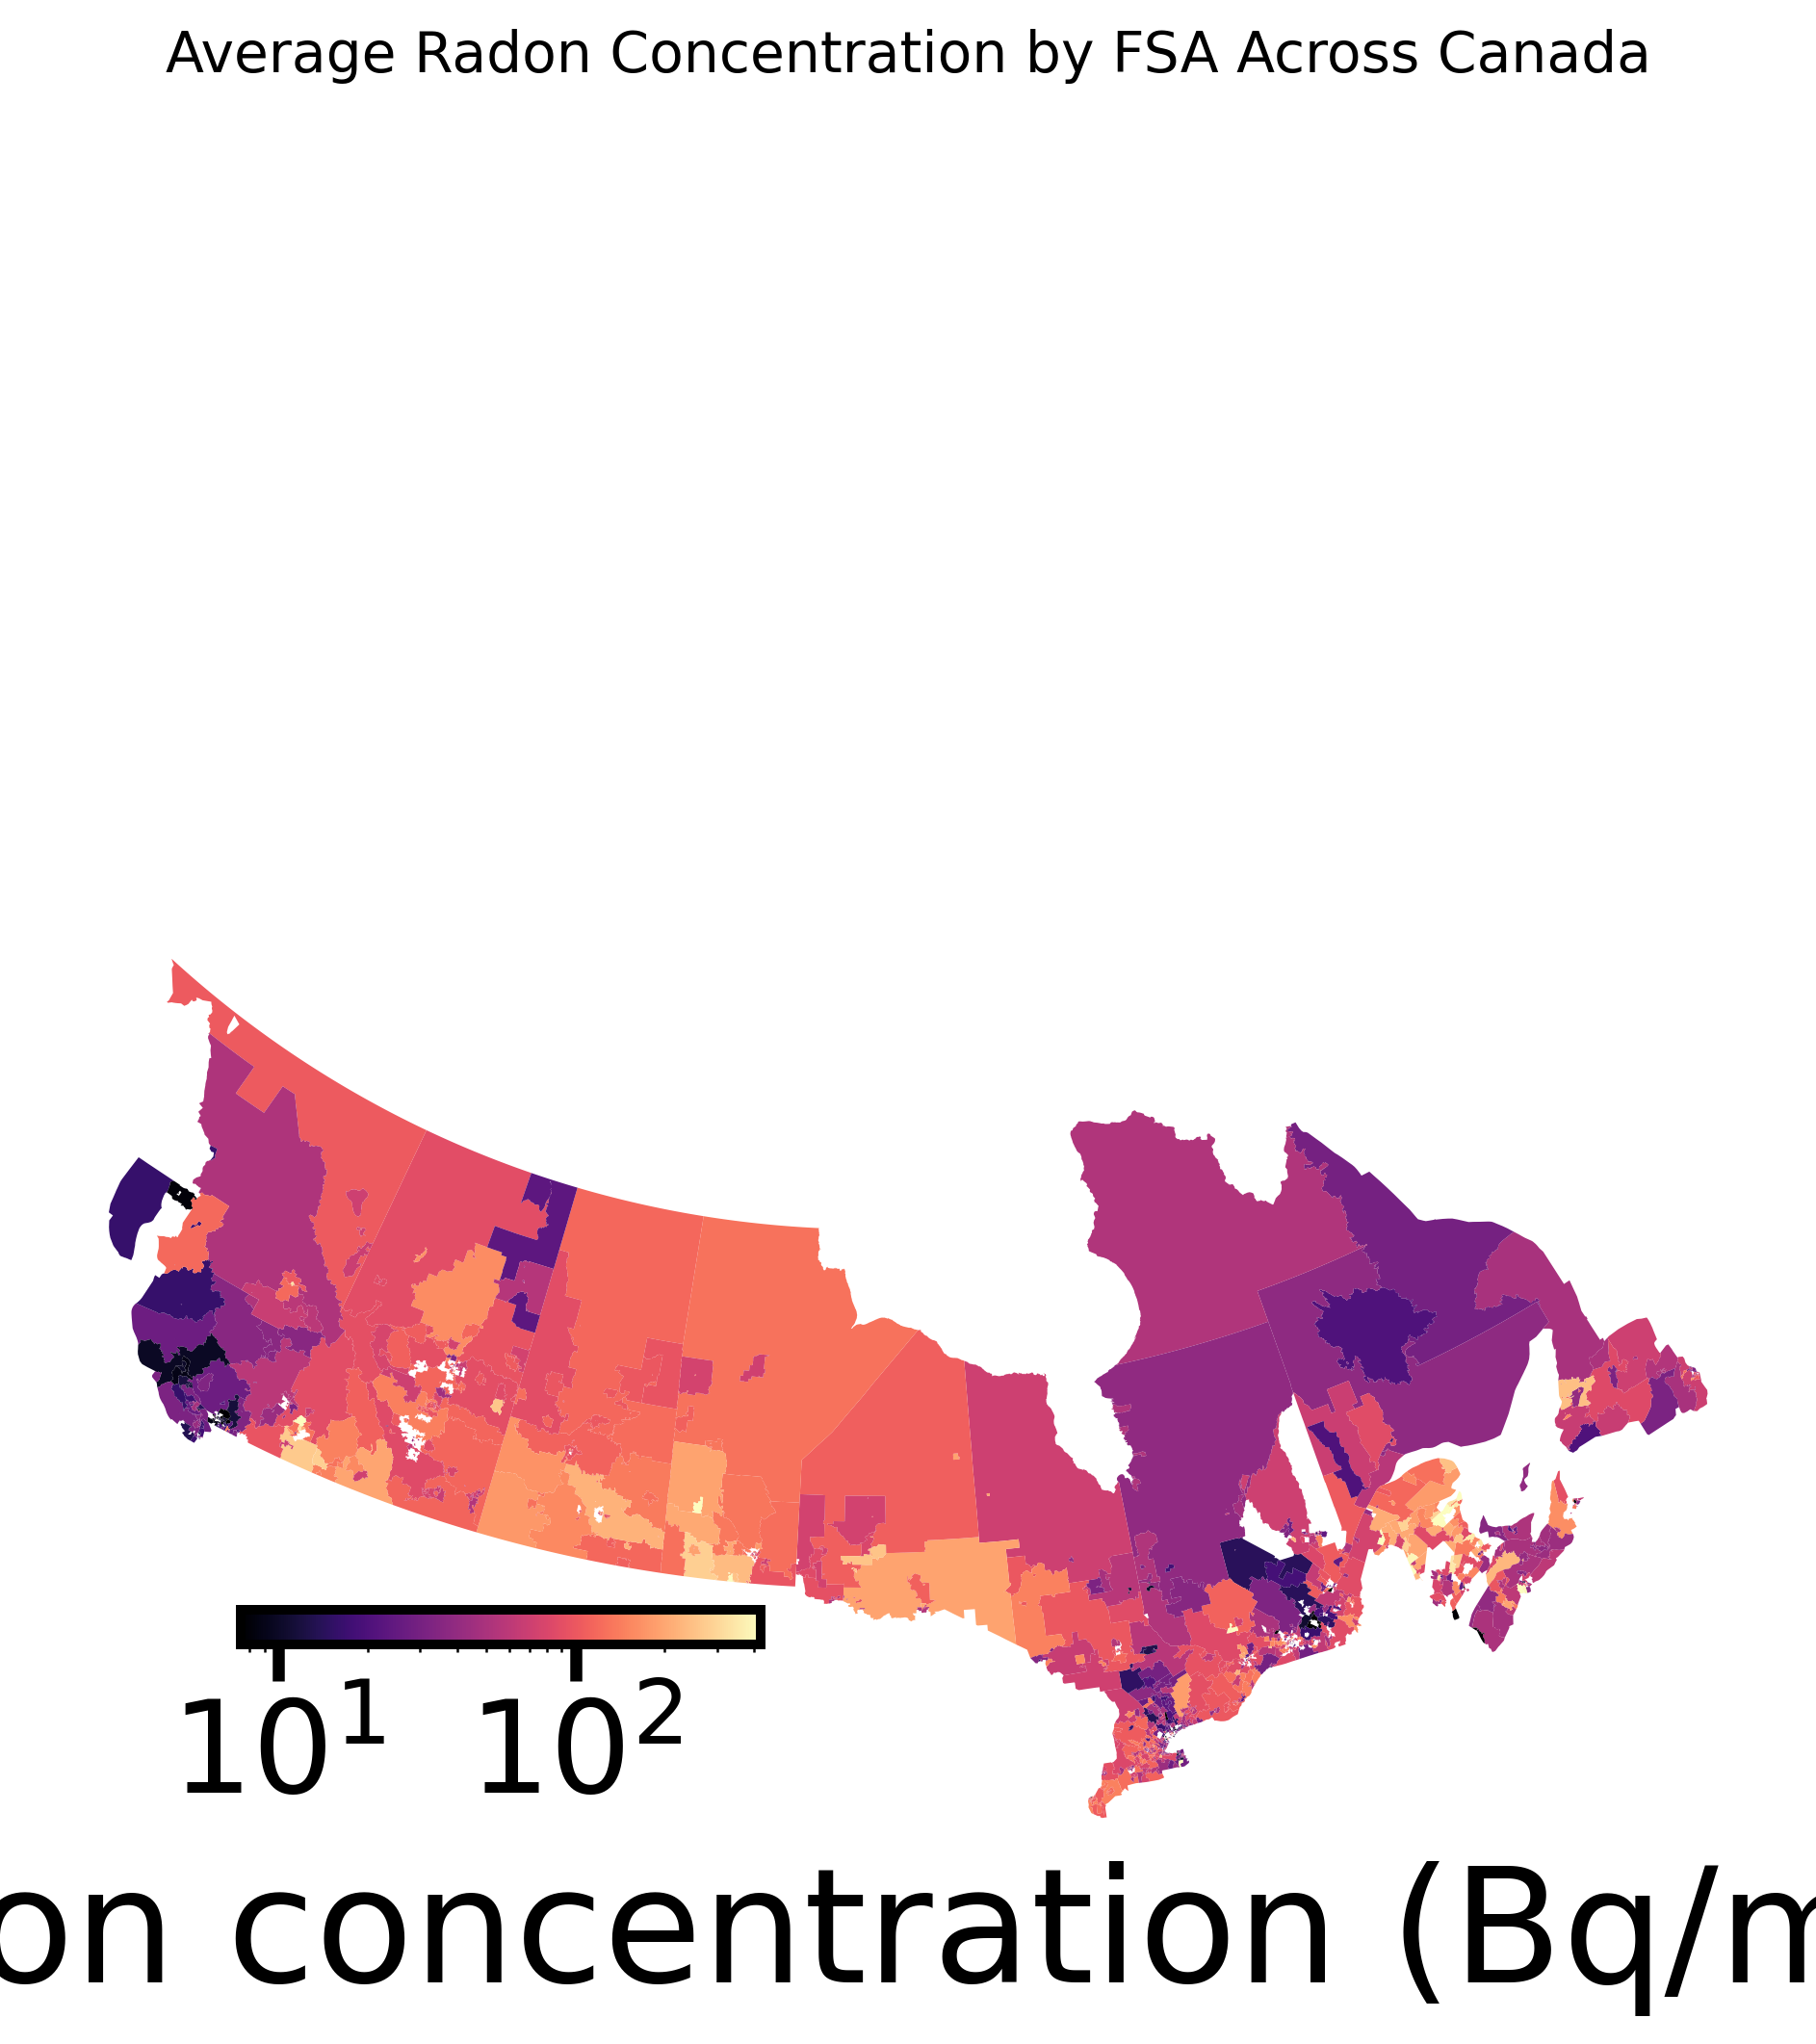

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

positive_values = fsa_map.loc[
    fsa_map["concentration_mean"].notna() & (fsa_map["concentration_mean"] > 0),
    "concentration_mean"
]

vmin = max(positive_values.min(), 1)
vmax = positive_values.quantile(0.99)

norm = LogNorm(vmin=vmin, vmax=vmax)
cmap = "magma"

# Main map
fsa_map.plot(
    column="concentration_mean",
    cmap=cmap,
    norm=norm,
    linewidth=0.05,
    edgecolor="none",
    legend=False,
    missing_kwds={
        "color": "none",   # use "white" if you prefer white instead of transparent
        "edgecolor": "none",
        "label": "No data"
    },
    ax=ax
)

ax.set_title(
    "Average Radon Concentration by FSA Across Canada",
    fontsize=14,
    pad=12
)
ax.set_axis_off()

# Horizontal colorbar across bottom
cax = fig.add_axes([0.32, 0.22, 0.15, 0.015])
cax.set_facecolor("none")

sm = ScalarMappable(norm=norm, cmap=cmap)
sm._A = []

cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")

cbar.set_label(
    "Average radon concentration (Bq/m³)",
    fontsize=40,
    labelpad=10
)

cbar.ax.tick_params(
    labelsize=32,
    width=3.0,
    length=9
)

cbar.outline.set_linewidth(2.4)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(2.4)

cbar.ax.set_facecolor("none")

plt.savefig(
    os.path.join(FIGURES_DIR, "average_radon_fsa_across_canada_map.png"),
    dpi=300,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

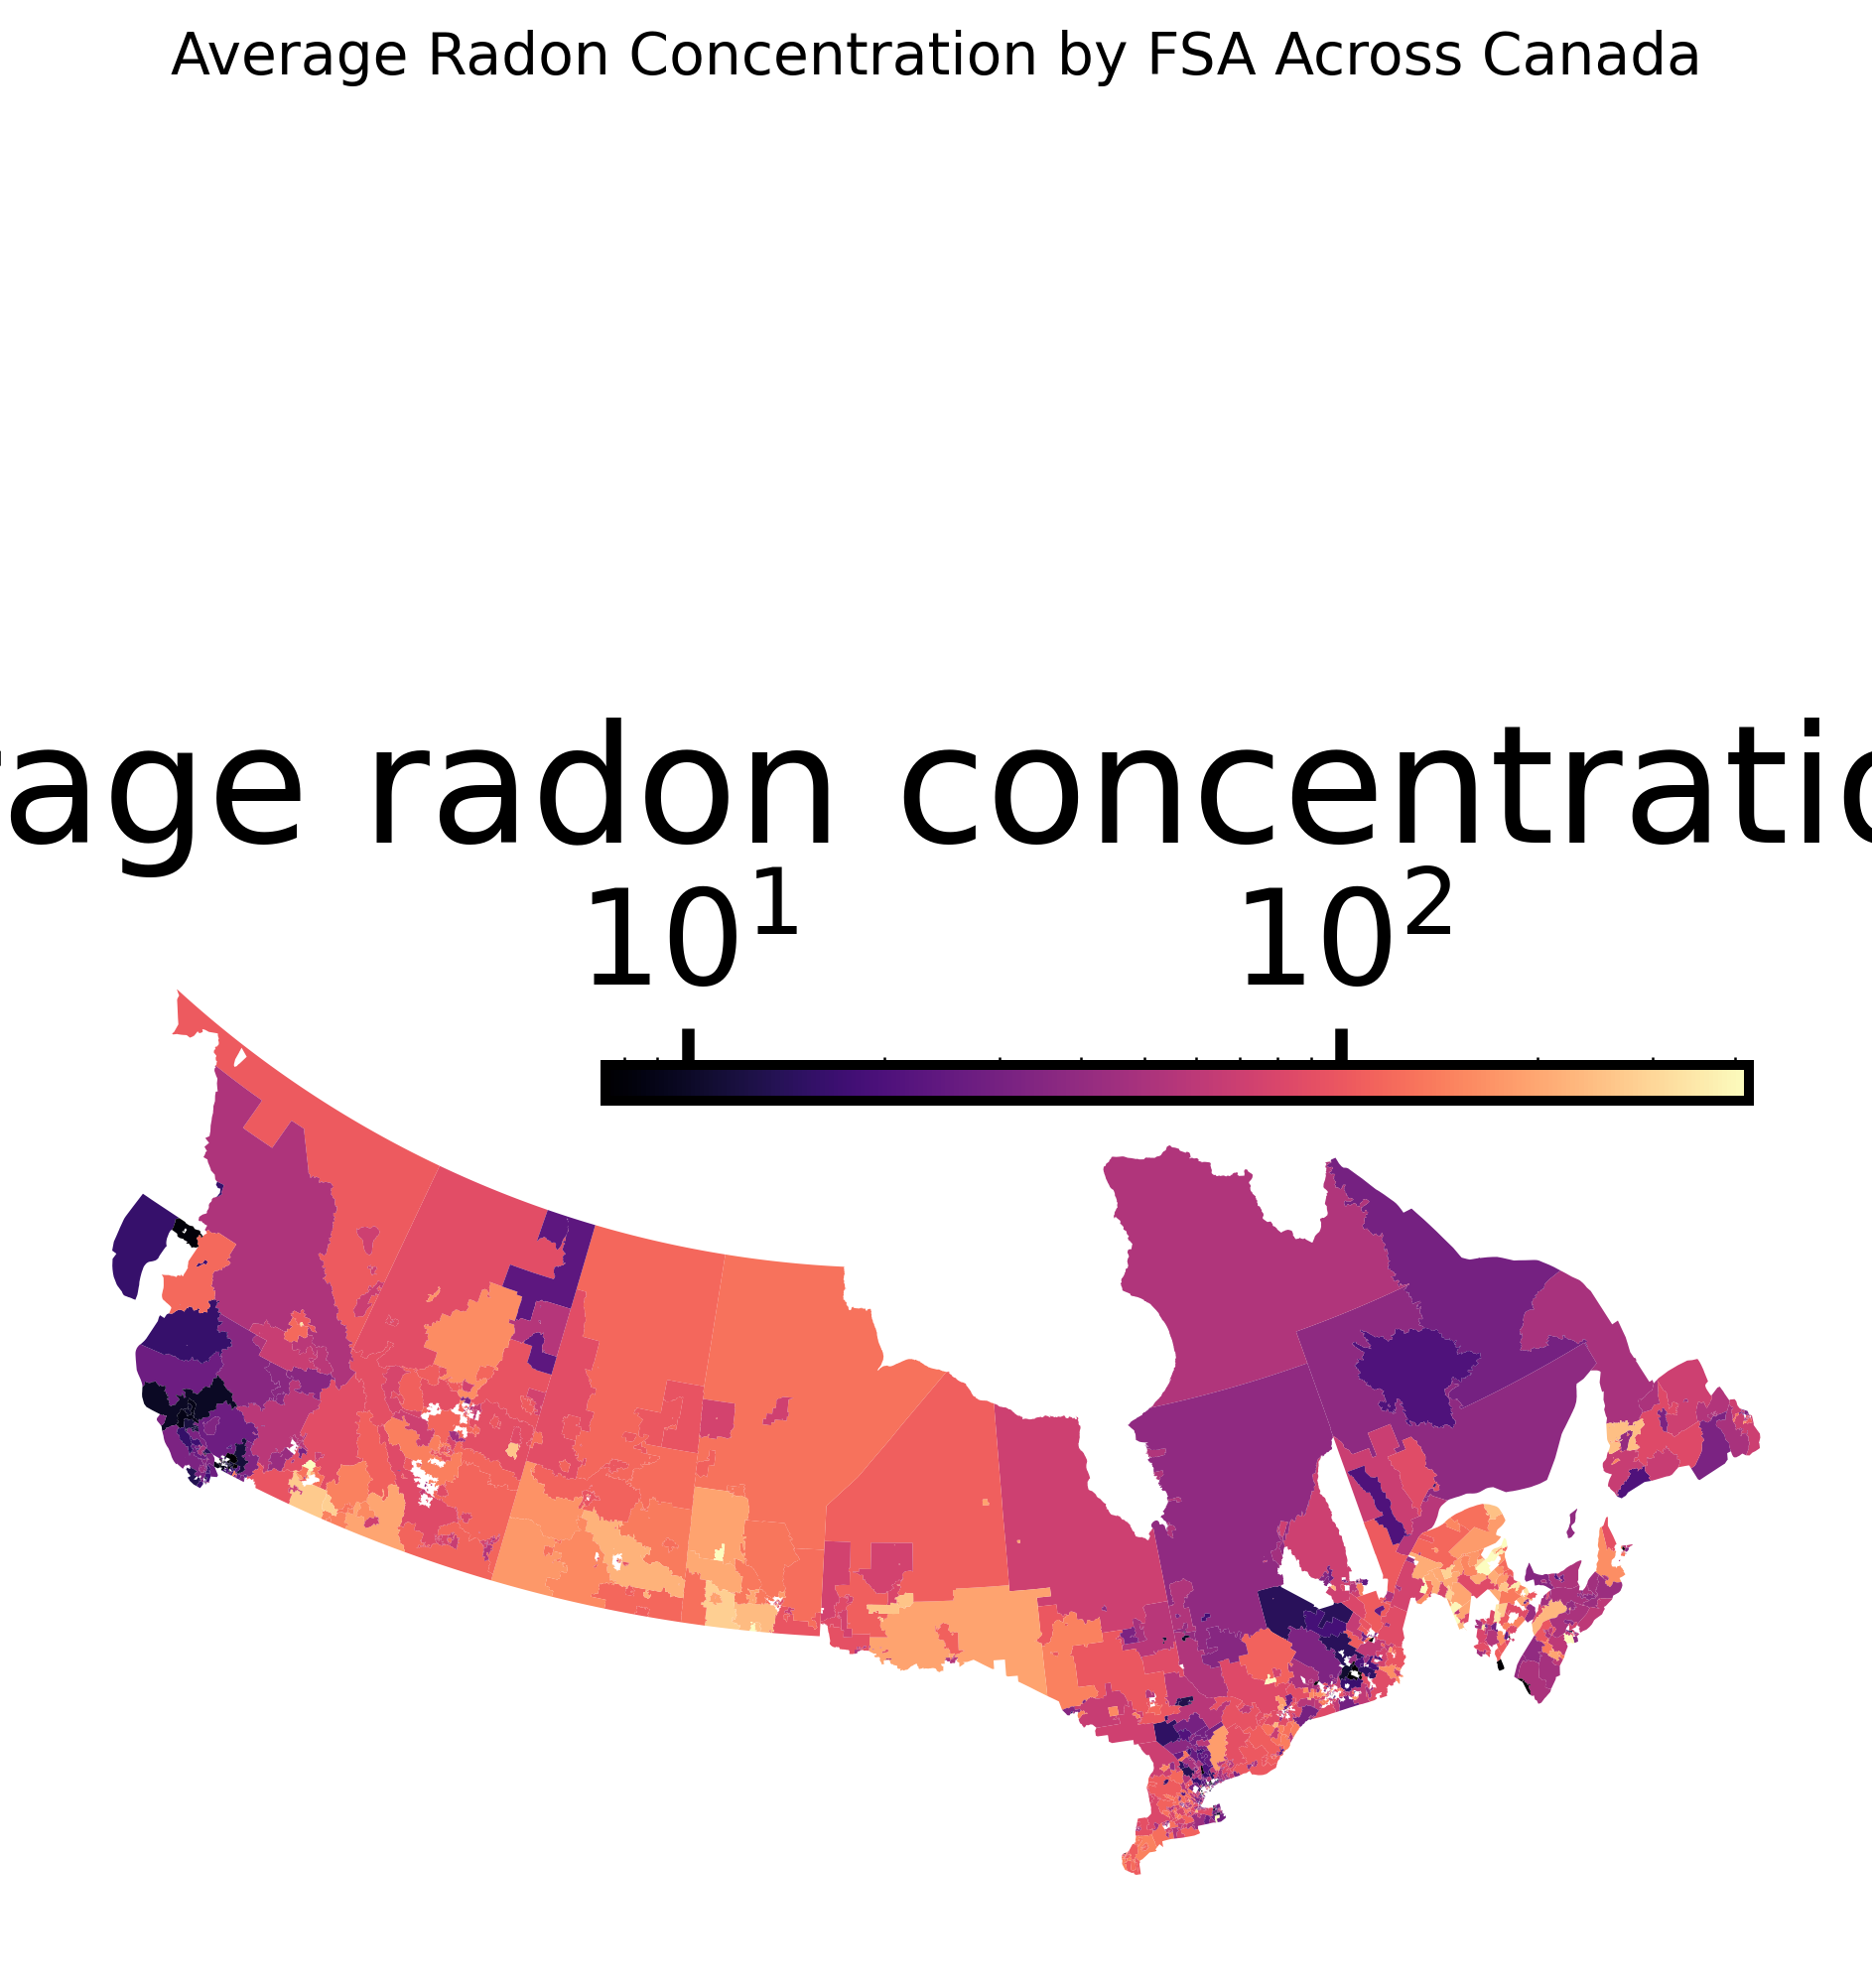

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# Color scaling from positive values only
positive_values = fsa_map.loc[
    fsa_map["concentration_mean"].notna() & (fsa_map["concentration_mean"] > 0),
    "concentration_mean"
]

vmin = max(positive_values.min(), 1)
vmax = positive_values.quantile(0.99)

norm = LogNorm(vmin=vmin, vmax=vmax)
cmap = "magma"

# Main map
fsa_map.plot(
    column="concentration_mean",
    cmap=cmap,
    norm=norm,
    linewidth=0.05,
    edgecolor="none",
    legend=False,
    missing_kwds={
        "color": "none",      # transparent no-data regions
        "edgecolor": "none",
        "label": "No data"
    },
    ax=ax
)

ax.set_title(
    "Average Radon Concentration by FSA Across Canada",
    fontsize=14,
    pad=12
)
ax.set_axis_off()

# ------------------------------------------------------------
# Horizontal colorbar at the top
# Same size as your requested box:
# [left, bottom, width, height]
# ------------------------------------------------------------
cax = fig.add_axes([0.42, 0.47, 0.32, 0.015])
cax.set_facecolor("none")

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")

# Put label and ticks above the bar
cbar.set_label(
    "Average radon concentration (Bq/m³)",
    fontsize=40,
    labelpad=10
)
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")

cbar.ax.tick_params(
    labelsize=32,
    width=3.0,
    length=9,
    labeltop=True,
    labelbottom=False,
    top=True,
    bottom=False
)

# Thicker lines around the legend
cbar.outline.set_linewidth(2.4)
for spine in cbar.ax.spines.values():
    spine.set_linewidth(2.4)

cbar.ax.set_facecolor("none")

# plt.savefig(
#     "average_radon_fsa_map.png",
#     dpi=300,
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0.05
# )

plt.show()